# US Firm Characteristics: Cost Sensitivity

**Chapter 18 - Transaction Costs and Execution**

Every Sharpe reported so far is net of one cost assumption: the commission and
slippage `setup.yaml` declares, charged on turnover at each rebalance. That is a
single number standing in for the whole of execution, and it was picked before any
of these strategies existed. This notebook asks what the result would have been had
that number been wrong.

The question is not whether costs matter but *how fast* the result decays as they
rise. A strategy whose Sharpe falls slowly across the grid is one whose edge is
large relative to what it pays to trade, and it can survive being wrong about
execution. One that falls off a cliff is being carried by the cost assumption
rather than by the signal, and the assumption is then the finding.

The declared level sits inside the swept range rather than at its edge, so the
curve shows the result both above and below what the other notebooks charged.

Sections 1-2 write cost-sensitivity backtests to the registry. Section 3 is
read-only and reads them back.

**Book Reference:** Chapter 18, Sections 18.2-18.5

**Prerequisites:** the Chapter 16 backtest and Chapter 17 allocation notebooks,
whose registered runs decide which strategy is swept here.

In [1]:
"""US Firm Characteristics: Costs."""

import json
import time
import warnings
from collections import Counter

import polars as pl

from utils.style import COLORS, add_message_title, show_with_alt

warnings.filterwarnings("ignore")

from case_studies.utils.backtest_loaders import get_backtest_config, load_backtest_prices_for
from case_studies.utils.backtest_presets import (
    clone_backtest_spec,
    ensure_backtest_spec,
    set_backtest_costs_bps,
    strategy_view,
)
from case_studies.utils.backtest_runner import run_backtest
from case_studies.utils.registry import (
    backtest_dir,
    load_existing_backtest_hashes,
    read_predictions,
    resolve_best_backtest_runs,
)
from case_studies.utils.sweep_config import get_cost_grid_bps, get_top_n_predictions
from utils.paths import get_case_study_dir

In [2]:
CASE_STUDY_ID = "us_firm_characteristics"
LABEL = ""
MAX_SYMBOLS = 0
TOP_N_COMBOS = None

In [3]:
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
bt_config = get_backtest_config(CASE_STUDY_ID)
if TOP_N_COMBOS is None:
    TOP_N_COMBOS = get_top_n_predictions(CASE_STUDY_ID, "cost_sensitivity")
if not LABEL:
    LABEL = bt_config.primary_label

print(f"Case study: {CASE_STUDY_ID}, label: {LABEL}")

COST_GRID_BPS = get_cost_grid_bps(CASE_STUDY_ID)

Case study: us_firm_characteristics, label: fwd_ret_1m


## 1. Which run is swept

The sweep starts from the highest-Sharpe validation run across *both* the
equal-weight baseline and the allocation stage. Both are candidates because an
allocator is an alternative to equal weighting rather than an improvement on it by
construction: where every allocator lands below the equal-weight parent it was built
from, an allocation-only rule would carry forward a strategy the previous notebook
measured as worse than doing nothing, and would then report that strategy's cost
sensitivity in place of the one a reader would trade.

Which stage the selected run came from is therefore printed rather than assumed.

In [4]:
def _resolve_pre_cost_runs(case_study: str, label: str, *, split: str, top_n: int) -> pl.DataFrame:
    candidates = [
        resolve_best_backtest_runs(
            case_study,
            label,
            split=split,
            stage=stage,
            top_n=top_n,
        )
        for stage in ("signal", "allocation")
    ]
    candidates = [frame for frame in candidates if not frame.is_empty()]
    if not candidates:
        return pl.DataFrame()
    return (
        pl.concat(candidates)
        .sort("sharpe", descending=True)
        .unique("backtest_hash", maintain_order=True)
        .head(top_n)
    )


top_combos = _resolve_pre_cost_runs(
    CASE_STUDY_ID,
    LABEL,
    split="validation",
    top_n=TOP_N_COMBOS,
)

if top_combos.is_empty():
    print("No baseline or allocation results found. Run the upstream notebooks first.")
else:
    for row in top_combos.iter_rows(named=True):
        spec = json.loads(row["spec_json"])
        alloc = strategy_view(spec).get("allocation", {}).get("method", "equal_weight")
        print(f"  Sharpe={row['sharpe']:.3f}  alloc={alloc}  bt_hash={row['backtest_hash'][:8]}")

  Sharpe=3.045  alloc=conformal_weighted  bt_hash=5721302d


In [5]:
prices = load_backtest_prices_for(CASE_STUDY_ID, LABEL, split="validation", max_symbols=MAX_SYMBOLS)
print(f"Prices: {len(prices):,} rows, {prices['symbol'].n_unique()} assets")

Prices: 252,008 rows, 3708 assets


## 2. Cost Grid Sweep

Each selected run is re-executed at every cost level in the declared grid, with
the level split evenly between commission and slippage. Nothing else about the
strategy changes, so the only thing separating one row from the next is what it
was charged to trade.

The grid and the strategy interact through turnover, which this panel keeps low by
rebalancing monthly: a cost level is paid once a month here rather than once a day,
so the same bps figure bites a monthly strategy far less than a daily one. That is
a property of the rebalance cadence, not a virtue of the signal, and it is the
reason the curve below can stay flat over a range that would destroy a
higher-frequency strategy.

A backtest hash covers the whole strategy spec, so a level already registered under
the same spec is served from the registry rather than recomputed. The summary below
reports two separate facts: what the stage contains, which is the same number whether
this execution was cold or warm and is what a reader needs, and what this execution
did, which is what a maintainer needs. Reported as one number they are
indistinguishable, and a warm re-run publishes a page claiming eleven backtests it
did not run.

The three execution counts sum to the levels attempted. `n_done` counts attempts, so a
failure has to come out of the computed figure or it is reported twice.

The reuse count asks `backtest_run_status`, which is the same call `run_backtest`
makes to decide, rather than checking the hash against a snapshot of the registry
taken before the loop. The two differ where a row is registered but has no
`daily_returns.parquet`: the runner recomputes it and a snapshot reports it as
reused, which is wrong in the direction that hides work.

`run_backtest` fills allocator defaults inside the call, so a hash built from the
spec this notebook holds is not necessarily the registered one. The set is keyed on
the hash the runner returns.

In [6]:
n_total = len(top_combos) * len(COST_GRID_BPS) if not top_combos.is_empty() else 0
n_done = 0
n_failed = 0
n_reused = 0
failures: Counter[str] = Counter()
reusable_before = {
    _hash
    for _hash in load_existing_backtest_hashes(CASE_STUDY_ID, stage="cost_sensitivity")
    if (backtest_dir(CASE_STUDY_ID, _hash) / "daily_returns.parquet").exists()
}
t0 = time.time()

for combo_row in top_combos.iter_rows(named=True):
    pred_hash = combo_row["prediction_hash"]
    base_spec = ensure_backtest_spec(
        CASE_STUDY_ID,
        bt_config,
        json.loads(combo_row["spec_json"]),
        prices=prices,
        prediction_hash=pred_hash,
        initial_cash=bt_config.initial_cash,
    )
    alloc_method = strategy_view(base_spec).get("allocation", {}).get("method", "equal_weight")

    predictions = read_predictions(CASE_STUDY_ID, pred_hash)

    for cost_bps in COST_GRID_BPS:
        n_done += 1

        spec = set_backtest_costs_bps(
            clone_backtest_spec(base_spec),
            commission_bps=cost_bps / 2,
            slippage_bps=cost_bps / 2,
        )
        spec["chapter"] = "ch18"

        try:
            result = run_backtest(
                CASE_STUDY_ID,
                pred_hash,
                spec,
                prices=prices,
                predictions=predictions,
                label=LABEL,
                register=True,
                initial_cash=bt_config.initial_cash,
                calendar=bt_config.calendar,
            )

            if result.backtest_hash in reusable_before:
                n_reused += 1
            print(
                f"  [{n_done}/{n_total}] {alloc_method} @ {cost_bps:g} bps: "
                f"Sharpe={result.metrics.get('sharpe', 0):.3f}"
            )
        except Exception as error:
            # Counted rather than swallowed: the summary below reports this count, and
            # the check after the loop refuses to go on when nothing was registered.
            n_failed += 1
            failures[f"{type(error).__name__}: {error}"] += 1
            print(
                f"  [{n_done}/{n_total}] {alloc_method} @ {cost_bps:g} bps: "
                f"FAILED - {type(error).__name__}: {error}"
            )

elapsed = time.time() - t0
stage_total = len(load_existing_backtest_hashes(CASE_STUDY_ID, stage="cost_sensitivity"))
print(f"\nCost-sensitivity stage: {stage_total} backtests registered.")
print(
    f"This execution: {n_done - n_reused - n_failed} computed, {n_reused} reused, "
    f"{n_failed} failed, over {n_done} of {n_total} declared levels "
    f"attempted in {elapsed:.0f}s."
)
for reason, count in failures.most_common():
    print(f"  {count:>3} x {reason[:150]}")

  SKIP backtest (complete (hash=6c8778c8bc6f)) — reusing cached result
  [1/11] conformal_weighted @ 0 bps: Sharpe=3.116
  SKIP backtest (complete (hash=0daef729cd40)) — reusing cached result
  [2/11] conformal_weighted @ 1 bps: Sharpe=3.110
  SKIP backtest (complete (hash=245802b3a472)) — reusing cached result
  [3/11] conformal_weighted @ 2 bps: Sharpe=3.104
  SKIP backtest (complete (hash=ab4af4d611d3)) — reusing cached result
  [4/11] conformal_weighted @ 3 bps: Sharpe=3.099
  SKIP backtest (complete (hash=8d6a71409678)) — reusing cached result
  [5/11] conformal_weighted @ 5 bps: Sharpe=3.087
  SKIP backtest (complete (hash=fb21a0332efa)) — reusing cached result
  [6/11] conformal_weighted @ 7 bps: Sharpe=3.076


  SKIP backtest (complete (hash=146e00b497d1)) — reusing cached result
  [7/11] conformal_weighted @ 10 bps: Sharpe=3.059
  SKIP backtest (complete (hash=6fb93dc55267)) — reusing cached result
  [8/11] conformal_weighted @ 15 bps: Sharpe=3.031


  SKIP backtest (complete (hash=6d32c875e2bc)) — reusing cached result
  [9/11] conformal_weighted @ 20 bps: Sharpe=3.003
  SKIP backtest (complete (hash=32666694cf65)) — reusing cached result
  [10/11] conformal_weighted @ 30 bps: Sharpe=2.947
  SKIP backtest (complete (hash=567c6cd7e7c5)) — reusing cached result
  [11/11] conformal_weighted @ 50 bps: Sharpe=2.834

Cost-sensitivity stage: 11 backtests registered.
This execution: 0 computed, 11 reused, 0 failed, over 11 of 11 declared levels attempted in 0s.


Section 3 reads the registry rather than the loop above, so a sweep that wrote nothing
and one that wrote everything look identical from there: the curve would be drawn from
whatever an earlier run left behind. Counting the failures is not enough on its own,
so the count stops the notebook.

Any failure stops it, not only a total one. Section 3 tells the reader that every level
is printed and that the top of the grid is what decides whether the curve reaches zero
inside it, so a single missing level can be the one the section is about. A grid with a
hole in it is not a smaller grid.

In [7]:
if n_failed:
    raise RuntimeError(
        f"{n_failed} of {n_total} cost levels failed, so the grid section 3 renders is "
        "incomplete. Its prose tells the reader every level is shown and that the top of "
        "the grid decides whether the curve reaches zero inside it, and a missing level "
        "may be exactly that one - so a partial sweep is not a partial result here."
    )

## 3. Cost Sensitivity Analysis

This section is **read-only**: it reads the cost-sensitivity rows back out of the
registry.

What to look for in the curve is its slope, not its height. The height is the
Sharpe already reported by the earlier notebooks and inherits their selection. The
slope is new information, and it says how much of that Sharpe was a claim about
execution rather than about the signal. A curve that reaches zero inside the grid
names the cost level at which the strategy stops being worth trading; one that does
not reach zero says only that the level is somewhere beyond the range tested, which
is a weaker statement than it looks.

In [8]:
from case_studies.utils.backtest_explorer import BacktestExplorer

explorer = BacktestExplorer(CASE_STUDY_ID)

The read is scoped to the prediction the sweep above carried. The cost-sensitivity
table accumulates across runs and labels, and the selection feeding this notebook
moves whenever an upstream stage is re-run, so an unscoped read pools the current
curve with every curve that preceded it and draws them as one series per allocator.

In [9]:
carriers = top_combos["prediction_hash"].unique().to_list() if not top_combos.is_empty() else []
frames = [explorer.cost_sensitivity(prediction_hash=h) for h in carriers]
frames = [frame for frame in frames if not frame.is_empty()]
cost_df = pl.concat(frames) if frames else pl.DataFrame()

The figure below shows the slope; this is the curve it is drawn from. A reader
comparing a decay rate against their own estimate of what they would pay needs the
levels themselves, and reading them off a line is not the same as having them. Every
level is printed rather than polars' default ten, so the top of the grid - the level
that decides whether the curve reaches zero inside it - is never the row that is
elided.

In [10]:
if cost_df.is_empty():
    print("No cost sensitivity data in registry")
else:
    with pl.Config(tbl_rows=cost_df.height):
        print(cost_df.sort("allocator", "cost_bps"))

shape: (11, 4)
┌──────────┬──────────┬──────────────┬────────────────────┐
│ cost_bps ┆ sharpe   ┆ max_drawdown ┆ allocator          │
│ ---      ┆ ---      ┆ ---          ┆ ---                │
│ f64      ┆ f64      ┆ f64          ┆ str                │
╞══════════╪══════════╪══════════════╪════════════════════╡
│ 0.0      ┆ 3.115538 ┆ -0.098297    ┆ conformal_weighted │
│ 1.0      ┆ 3.109923 ┆ -0.098734    ┆ conformal_weighted │
│ 2.0      ┆ 3.104306 ┆ -0.09917     ┆ conformal_weighted │
│ 3.0      ┆ 3.098688 ┆ -0.099607    ┆ conformal_weighted │
│ 5.0      ┆ 3.08745  ┆ -0.100479    ┆ conformal_weighted │
│ 7.0      ┆ 3.076207 ┆ -0.101351    ┆ conformal_weighted │
│ 10.0     ┆ 3.059336 ┆ -0.102657    ┆ conformal_weighted │
│ 15.0     ┆ 3.031198 ┆ -0.10483     ┆ conformal_weighted │
│ 20.0     ┆ 3.003034 ┆ -0.107       ┆ conformal_weighted │
│ 30.0     ┆ 2.946634 ┆ -0.111326    ┆ conformal_weighted │
│ 50.0     ┆ 2.833547 ┆ -0.119929    ┆ conformal_weighted │
└──────────┴──────────┴──

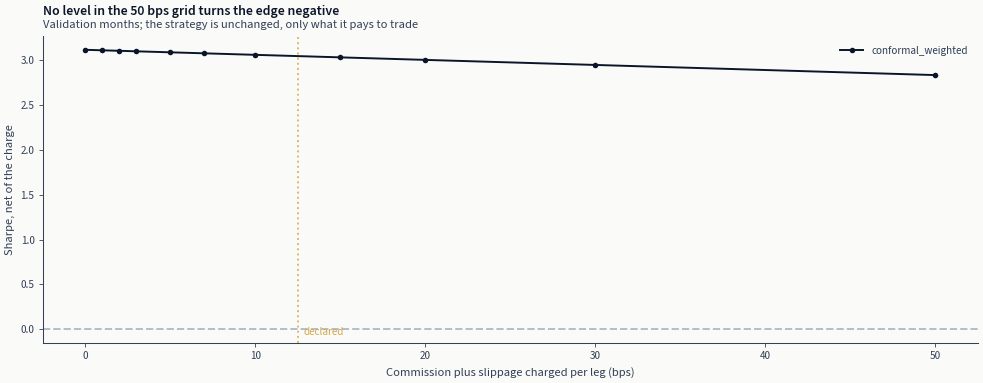

In [11]:
import matplotlib.pyplot as plt

if not cost_df.is_empty():
    fig, ax = plt.subplots(figsize=(10, 4))

    for alloc in cost_df["allocator"].unique().sort().to_list():
        subset = cost_df.filter(pl.col("allocator") == alloc).sort("cost_bps")
        ax.plot(subset["cost_bps"].to_list(), subset["sharpe"].to_list(), marker="o", label=alloc)

    ax.axhline(0, color=COLORS["recede"], linestyle="--", alpha=0.7)
    # The declared level, so the reader can see which part of the curve the rest of
    # the case study was run on and which part is the counterfactual.
    declared_bps = bt_config.commission_bps + bt_config.slippage_bps
    ax.axvline(declared_bps, color=COLORS["amber"], linestyle=":", alpha=0.8)
    ax.annotate(
        "declared",
        xy=(declared_bps, ax.get_ylim()[0]),
        xytext=(4, 6),
        textcoords="offset points",
        fontsize=8,
        color=COLORS["amber"],
    )
    ax.set_xlabel("Commission plus slippage charged per leg (bps)")
    ax.set_ylabel("Sharpe, net of the charge")
    add_message_title(
        ax,
        "No level in the 50 bps grid turns the edge negative",
        subtitle="Validation months; the strategy is unchanged, only what it pays to trade",
    )
    ax.legend(frameon=False)
    fig.tight_layout()
    show_with_alt(
        fig,
        "Line chart of validation Sharpe against the total commission and slippage "
        "charged per leg, from zero to fifty basis points. The line starts just above "
        "3.1 and falls almost straight to about 2.8 at the right edge, staying far "
        "above the dashed zero reference across the whole grid. A dotted vertical "
        "marker near the left shows the cost level the rest of the case study was "
        "charged at, with most of the swept range lying to its right.",
    )

## What this notebook establishes, and what it does not

The curve is a statement about one strategy, not about the surface. It re-runs the
single highest-Sharpe validation run at each cost level, so it answers how *that*
result would have moved had execution been priced differently. It does not say
whether a different strategy would have been chosen under a different cost
assumption, which is a larger question: the selection that produced this run was
itself made on results charged at the declared level.

The height of the curve carries the selection of every stage before it and should
not be read as an estimate of what the strategy would earn. The slope is the part
that is this notebook's own, and it is what the strategy analysis notebook uses.

These are validation months throughout. Nothing here reads or selects on the holdout
period, which stays untouched until the strategy analysis notebook.

**Next:** the risk management notebook asks whether a stop-loss or a time exit can
be evaluated on this backtest path at all, before asking what one would cost.